In [5]:
# ============================================================
# 공통 준비
# ============================================================

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(tf.__version__)

2.21.0


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8137 - loss: 0.5159 - val_accuracy: 0.8840 - val_loss: 0.3176
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8782 - loss: 0.3408 - val_accuracy: 0.8959 - val_loss: 0.2781
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8949 - loss: 0.2930 - val_accuracy: 0.9007 - val_loss: 0.2654
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9054 - loss: 0.2602 - val_accuracy: 0.9076 - val_loss: 0.2523
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9150 - loss: 0.2323 - val_accuracy: 0.9121 - val_loss: 0.2323
(3, 3, 1, 32)


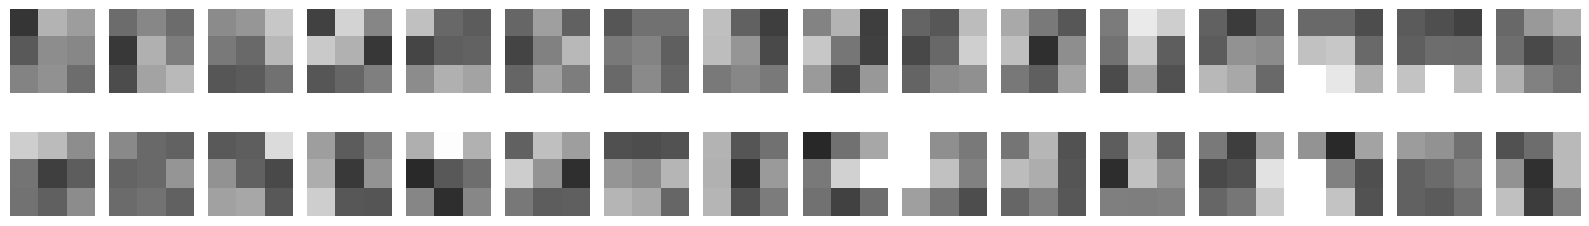

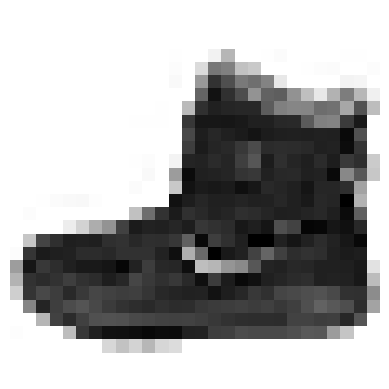

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1번째 Conv 출력: (1, 28, 28, 32)
2번째 Conv 출력: (1, 14, 14, 64)


In [6]:
# ============================================================
# 교재 08-3 재현
# ============================================================

from tensorflow.keras.datasets import fashion_mnist

(train_input, train_target), (test_input, test_target) = fashion_mnist.load_data()

train_scaled = train_input.reshape(-1, 28, 28, 1) / 255.0
test_scaled = test_input.reshape(-1, 28, 28, 1) / 255.0

model = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, kernel_size=3, activation="relu", padding="same", name="conv1"),
    layers.MaxPooling2D(2),

    layers.Conv2D(64, kernel_size=3, activation="relu", padding="same", name="conv2"),
    layers.MaxPooling2D(2),

    layers.Flatten(),
    layers.Dense(100, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(10, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    train_scaled,
    train_target,
    epochs=5,
    validation_split=0.2,
    verbose=1
)

conv = model.get_layer("conv1")
weights, biases = conv.get_weights()

print(weights.shape)

fig, axs = plt.subplots(2, 16, figsize=(16, 3))  # Conv 가중치 2x16 그리드(vmin/vmax 포함)

for i in range(2):
    for j in range(16):
        idx = i * 16 + j
        axs[i, j].imshow(
            weights[:, :, 0, idx],
            cmap="gray_r",
            vmin=-0.5,
            vmax=0.5
        )
        axs[i, j].axis("off")

plt.tight_layout()
plt.show()

ankle_boot_index = np.where(train_target == 9)[0][0]
ankle_boot = train_scaled[ankle_boot_index:ankle_boot_index + 1]

plt.imshow(ankle_boot[0, :, :, 0], cmap="gray_r")
plt.axis("off")
plt.show()

conv_output_model = keras.Model(  # 함수형 API 모델
    inputs=model.inputs,
    outputs=[
        model.get_layer("conv1").output,
        model.get_layer("conv2").output
    ]
)

conv1_output, conv2_output = conv_output_model.predict(ankle_boot)  # ankle boot 특성 맵 1번째·2번째 Conv 출력

print("1번째 Conv 출력:", conv1_output.shape)  # 특성 맵 shape (1,28,28,32)
print("2번째 Conv 출력:", conv2_output.shape)  # (1,14,14,64)

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: C:\Program Files\Python314\python.exe -m pip install --upgrade pip


,conf,탐지 개수,탐지 객체
0,0.10,6,"{'bus': 1, 'person': 4, 'stop sign': 1}"
1,0.25,6,"{'bus': 1, 'person': 4, 'stop sign': 1}"
2,0.50,4,"{'bus': 1, 'person': 3}"
3,0.70,4,"{'bus': 1, 'person': 3}"


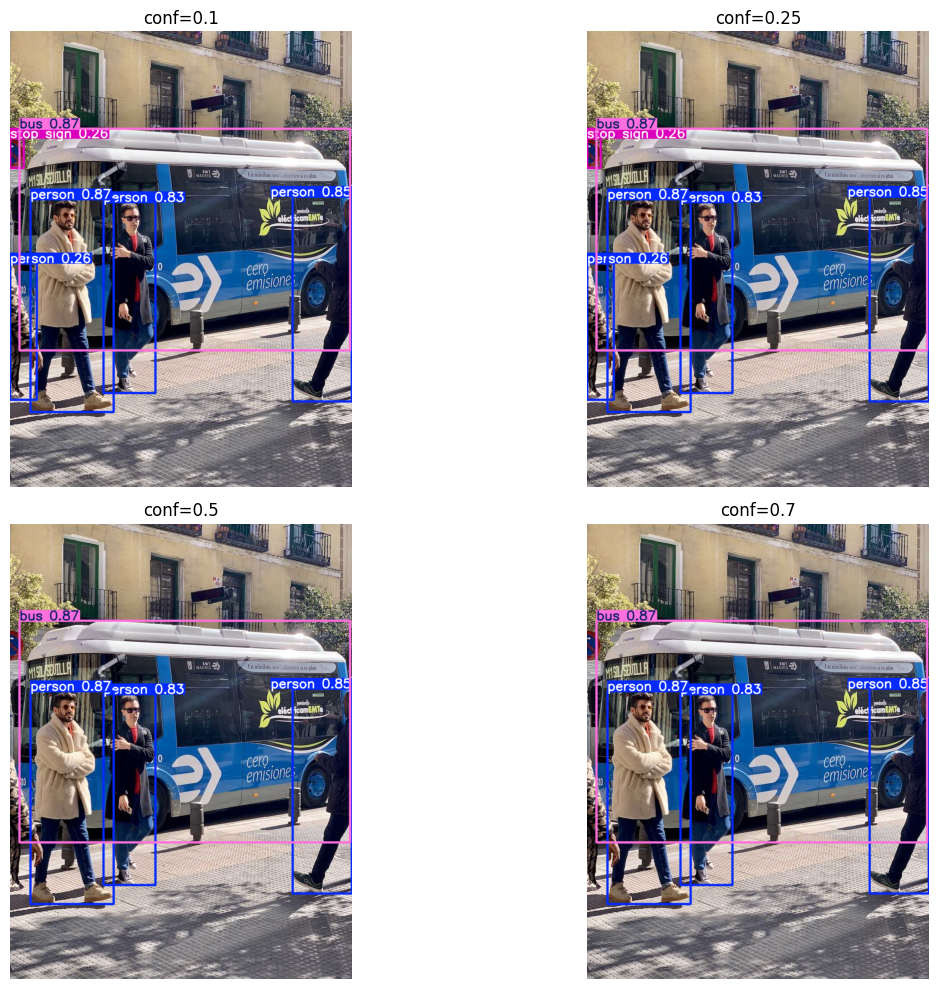

conf를 너무 낮추면 오탐이 늘어나고, 너무 높이면 실제 객체도 놓치는 미탐이 늘어난다.


In [7]:
# ============================================================
# YOLO conf 임계값 실험
# ============================================================

!pip install ultralytics -q

from ultralytics import YOLO
import cv2
import urllib.request
from collections import Counter

yolo_model = YOLO("yolov8n.pt")

img_url = "https://ultralytics.com/images/bus.jpg"
img_path = "yolo_test_image.jpg"
urllib.request.urlretrieve(img_url, img_path)

conf_list = [0.1, 0.25, 0.5, 0.7]  # conf={0.1, 0.25, 0.5, 0.7}

rows = []
images = {}

for conf in conf_list:
    result = yolo_model(img_path, conf=conf, verbose=False)[0]

    boxes = result.boxes
    detected_names = []

    for box in boxes:
        cls_id = int(box.cls[0])
        detected_names.append(yolo_model.names[cls_id])

    class_count = Counter(detected_names)

    rows.append({
        "conf": conf,
        "탐지 개수": len(boxes),
        "탐지 객체": dict(class_count)
    })

    plotted = result.plot()
    images[conf] = cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB)

yolo_df = pd.DataFrame(rows)  # 탐지 개수 비교
display(yolo_df)

fig, axs = plt.subplots(2, 2, figsize=(14, 10))  # 사라진 객체 직접 확인

for ax, conf in zip(axs.ravel(), conf_list):
    ax.imshow(images[conf])
    ax.set_title(f"conf={conf}")
    ax.axis("off")

plt.tight_layout()
plt.show()

print("conf를 너무 낮추면 오탐이 늘어나고, 너무 높이면 실제 객체도 놓치는 미탐이 늘어난다.")  # 임계값 선택 기준 한 문장

In [8]:
# ============================================================
# CIFAR-10 전이학습/Fine-Tuning
# ============================================================

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

y_train = y_train.reshape(-1)
y_test = y_test.reshape(-1)

IMG_SIZE = 96
BATCH_SIZE = 64

TRAIN_LIMIT = 10000
VAL_LIMIT = 3000

x_train_small = x_train[:TRAIN_LIMIT]
y_train_small = y_train[:TRAIN_LIMIT]

x_val = x_train[TRAIN_LIMIT:TRAIN_LIMIT + VAL_LIMIT]
y_val = y_train[TRAIN_LIMIT:TRAIN_LIMIT + VAL_LIMIT]

train_ds = tf.data.Dataset.from_tensor_slices((x_train_small, y_train_small))
train_ds = train_ds.shuffle(5000, seed=SEED).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((x_val, y_val))
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.1)
])

scratch_model = keras.Sequential([
    keras.Input(shape=(32, 32, 3)),
    layers.Resizing(IMG_SIZE, IMG_SIZE),
    data_augmentation,
    layers.Rescaling(1.0 / 255),

    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),
    layers.Dense(10, activation="softmax")
])

scratch_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_scratch = scratch_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    verbose=1
)

base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

inputs = keras.Input(shape=(32, 32, 3))
x = layers.Resizing(IMG_SIZE, IMG_SIZE)(inputs)
x = data_augmentation(x)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(10, activation="softmax")(x)

transfer_model = keras.Model(inputs, outputs)

transfer_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_feature = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    verbose=1
)  # MobileNetV2 Feature Extraction

base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

transfer_model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_fine = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    verbose=1
)  # Fine-Tuning 2단계

scratch_best = max(history_scratch.history["val_accuracy"])
feature_best = max(history_feature.history["val_accuracy"])
fine_best = max(history_fine.history["val_accuracy"])

cifar_df = pd.DataFrame({
    "모델": [
        "from scratch",
        "MobileNetV2 Feature Extraction",
        "Fine-Tuning"
    ],
    "val_accuracy": [
        scratch_best,
        feature_best,
        fine_best
    ]
})  # from scratch 대비 val_accuracy 비교

display(cifar_df)

print("전이학습은 ImageNet에서 미리 학습한 시각 특징을 재사용하기 때문에 적은 에포크로도 더 높은 성능을 낼 수 있다.")  # 왜 전이학습이 적은 에포크로 더 높은 성능을 내는가 분석

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 26s 161ms/step - accuracy: 0.1734 - loss: 2.1661 - val_accuracy: 0.2160 - val_loss: 2.0314
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 30s 188ms/step - accuracy: 0.2288 - loss: 2.0413 - val_accuracy: 0.2460 - val_loss: 2.0108
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 30s 191ms/step - accuracy: 0.2509 - loss: 1.9868 - val_accuracy: 0.2433 - val_loss: 2.0213
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 30s 191ms/step - accuracy: 0.2752 - loss: 1.9280 - val_accuracy: 0.3137 - val_loss: 1.8784
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 30s 192ms/step - accuracy: 0.2976 - loss: 1.8830 - val_accuracy: 0.3400 - val_loss: 1.8281
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 32s 182ms/step - accuracy: 0.5382 - loss: 1.4073 - val_accuracy: 0.7680 - val_loss: 0.6678
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 28s 179ms/step - accuracy: 0.6919 - loss: 0.8939 - val_accuracy: 0.8003 - val_loss: 0.5840
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 27

,모델,val_accuracy
0,from scratch,0.340000
1,MobileNetV2 Feature Extraction,0.823333
2,Fine-Tuning,0.843667


전이학습은 ImageNet에서 미리 학습한 시각 특징을 재사용하기 때문에 적은 에포크로도 더 높은 성능을 낼 수 있다.


In [9]:
# ============================================================
# 제출 안내
# ============================================================

print("BASIC")  # 08-3 재현 노트북
print("32개 필터 그리드 이미지")
print("특성 맵 shape:", conv1_output.shape, conv2_output.shape)  # (1,28,28,32) + (1,14,14,64) 출력 스크린샷

print("APPLIED")
display(yolo_df)  # conf 임계값 비교표(conf=0.1/0.25/0.5/0.7 탐지 개수)
print("conf를 너무 낮추면 오탐이 늘어나고, 너무 높이면 미탐이 늘어난다.")  # 너무 낮추면/높이면 어떤 문제? 한 문장

print("CHALLENGE")
display(cifar_df)  # from scratch vs 전이학습 vs Fine-Tuning val_accuracy 비교표 3개
print("전이학습은 기존에 학습된 시각 특징을 재사용하기 때문에 효과적이다.")  # 전이학습이 효과적인 이유 한 문장

BASIC
32개 필터 그리드 이미지
특성 맵 shape: (1, 28, 28, 32) (1, 14, 14, 64)
APPLIED


,conf,탐지 개수,탐지 객체
0,0.10,6,"{'bus': 1, 'person': 4, 'stop sign': 1}"
1,0.25,6,"{'bus': 1, 'person': 4, 'stop sign': 1}"
2,0.50,4,"{'bus': 1, 'person': 3}"
3,0.70,4,"{'bus': 1, 'person': 3}"


conf를 너무 낮추면 오탐이 늘어나고, 너무 높이면 미탐이 늘어난다.
CHALLENGE


,모델,val_accuracy
0,from scratch,0.340000
1,MobileNetV2 Feature Extraction,0.823333
2,Fine-Tuning,0.843667


전이학습은 기존에 학습된 시각 특징을 재사용하기 때문에 효과적이다.
